# Introduction to Machine Learning: Linear Regression

## Welcome to Machine Learning!

This tutorial introduces you to **Machine Learning** through one of the most fundamental algorithms: **Linear Regression**. You'll learn both the theory and practice, building models from scratch and using professional tools.

### **What You'll Learn:**

✅ **What is Machine Learning?**
- Supervised vs Unsupervised Learning
- Regression vs Classification
- The Machine Learning workflow

✅ **Linear Regression Theory**
- Mathematical foundations
- How the algorithm works
- Cost functions and optimization

✅ **Practical Implementation**
- Building from scratch
- Using scikit-learn
- Real-world datasets

✅ **Model Evaluation**
- Understanding metrics (R², MSE, MAE)
- Visualizing predictions
- Residual analysis

✅ **Advanced Topics**
- Multiple Linear Regression
- Polynomial Regression
- Regularization (Ridge, Lasso)

---

## Table of Contents
1. [Introduction to Machine Learning](#1)
2. [What is Linear Regression?](#2)
3. [Mathematical Foundation](#3)
4. [Simple Linear Regression - Theory](#4)
5. [Implementation from Scratch](#5)
6. [Example 1: Salary Prediction](#6)
7. [Using Scikit-learn](#7)
8. [Model Evaluation Metrics](#8)
9. [Example 2: House Price Prediction](#9)
10. [Multiple Linear Regression](#10)
11. [Polynomial Regression](#11)
12. [Regularization Techniques](#12)
13. [Best Practices & Conclusion](#13)

In [7]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression #, Ridge, Lasso
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


All libraries imported successfully!
NumPy version: 2.3.5
Pandas version: 3.0.1


---

# 1. Introduction to Machine Learning <a id="1"></a>

### What is Machine Learning?

**Machine Learning** is a subset of Artificial Intelligence that enables computers to learn from data without being explicitly programmed. Instead of writing specific rules, we feed data to algorithms that learn patterns and make predictions.

**Traditional Programming vs Machine Learning:**

```
Traditional Programming:
Data + Rules → Computer → Output

Machine Learning:
Data + Output → Computer → Rules (Model)
```

### Types of Machine Learning

#### 1️⃣ **Supervised Learning** (We'll focus on this!)
- **Definition**: Learning from labeled data (input-output pairs)
- **Goal**: Learn a mapping function from inputs to outputs
- **Examples**: 
  - Predicting house prices given features (Regression)
  - Classifying emails as spam/not spam (Classification)

#### 2️⃣ **Unsupervised Learning**
- **Definition**: Learning from unlabeled data
- **Goal**: Discover hidden patterns or structures
- **Examples**: Customer segmentation, anomaly detection

#### 3️⃣ **Reinforcement Learning**
- **Definition**: Learning through trial and error with rewards
- **Examples**: Game playing, robotics

### Supervised Learning: Regression vs Classification

| Aspect | Regression | Classification |
|--------|------------|----------------|
| **Output** | Continuous values (numbers) | Discrete categories (labels) |
| **Examples** | Price, temperature, salary | Spam/Ham, Cat/Dog, Disease/Healthy |
| **Algorithms** | Linear Regression, Ridge, Lasso | Logistic Regression, SVM, Random Forest |
| **Goal** | Predict quantity | Predict category |

**We focus on Regression - specifically Linear Regression!**

### Let's Visualize the difference between Regression and Classification

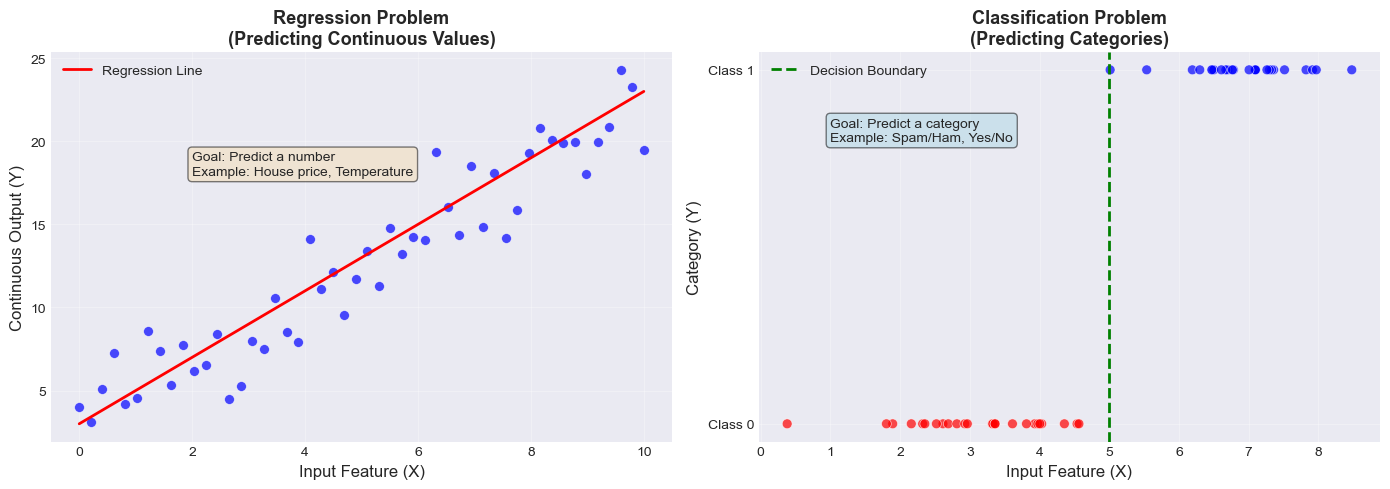


 Key Difference:
   Regression → Predicts numbers (continuous)
   Classification → Predicts categories (discrete)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression Example
np.random.seed(42)
X_reg = np.linspace(0, 10, 50) 
y_reg = 2 * X_reg + 3 + np.random.normal(0, 2, 50)

axes[0].scatter(X_reg, y_reg, alpha=0.7, s=50, color='blue', edgecolors='white', linewidth=0.5)
axes[0].plot(X_reg, 2*X_reg + 3, 'r-', linewidth=2, label='Regression Line')
axes[0].set_xlabel('Input Feature (X)', fontsize=12)
axes[0].set_ylabel('Continuous Output (Y)', fontsize=12)
axes[0].set_title('Regression Problem\n(Predicting Continuous Values)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(2, 18, 'Goal: Predict a number\nExample: House price, Temperature', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)

# Classification Example
X_class = np.concatenate([np.random.normal(3, 1, 25), np.random.normal(7, 1, 25)])
y_class = np.concatenate([np.zeros(25), np.ones(25)])

colors = ['red' if y == 0 else 'blue' for y in y_class]
axes[1].scatter(X_class, y_class, c=colors, alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
axes[1].axvline(x=5, color='green', linestyle='--', linewidth=2, label='Decision Boundary')
axes[1].set_xlabel('Input Feature (X)', fontsize=12)
axes[1].set_ylabel('Category (Y)', fontsize=12)
axes[1].set_title('Classification Problem\n(Predicting Categories)', fontsize=13, fontweight='bold')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Class 0', 'Class 1'])
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].text(1, 0.8, 'Goal: Predict a category\nExample: Spam/Ham, Yes/No', 
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5), fontsize=10)

plt.tight_layout()
plt.show()

print("\n Key Difference:")
print("   Regression → Predicts numbers (continuous)")
print("   Classification → Predicts categories (discrete)")

### The Machine Learning Workflow

Every ML project follows a similar workflow:

```
1. Collect Data
   ↓
2. Explore & Visualize
   ↓
3. Preprocess & Clean
   ↓
4. Split Data (Train/Test)
   ↓
5. Choose Algorithm
   ↓
6. Train Model
   ↓
7. Evaluate Performance
   ↓
8. Tune & Improve
   ↓
9. Deploy & Monitor
```

This workflow is quite standard throughout all ML tasks!

## 2. What is Linear Regression? <a id="2"></a>

### Definition

**Linear Regression** is a supervised learning algorithm that models the relationship between:
- **Input variable(s)** (features, independent variables, X)
- **Output variable** (target, dependent variable, Y)

using a **linear equation** (straight line).

### The Linear Equation

For **Simple Linear Regression** (one feature):

$$y = mx + b$$

Or in ML notation:

$$\hat{y} = \theta_0 + \theta_1 x$$

Where:
- $\hat{y}$ (y-hat) = predicted value
- $x$ = input feature
- $\theta_0$ = intercept (bias term) - where the line crosses the y-axis
- $\theta_1$ = slope (weight) - how much y changes when x increases by 1

### Real-World Example

**Predicting Salary from Years of Experience:**

If we find: $\text{Salary} = 30,000 + 5,000 \times \text{Years}$

- **Intercept (30,000)**: Starting salary with 0 years experience
- **Slope (5,000)**: Salary increase per year of experience

So someone with 5 years experience:
$$\text{Salary} = 30,000 + 5,000 \times 5 = 55,000$$

### Key Assumptions

Linear Regression assumes:
1. **Linearity**: Relationship between X and Y is linear
2. **Independence**: Observations are independent
3. **Homoscedasticity**: Constant variance of errors - i.e. differences between y and predictions is constant through the dataset
4. **Normality**: Errors are normally distributed

### Check it out with synthetic data

In [19]:
# Generate sample data
np.random.seed(42)
years_experience = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
salary = 30000 + 5000 * years_experience + np.random.normal(0, 3000, 10)

# Fit a line
theta_1 = np.cov(years_experience, salary)[0, 1] / np.var(years_experience)
theta_0 = np.mean(salary) - theta_1 * np.mean(years_experience)


### Visualize what Linear Regression does

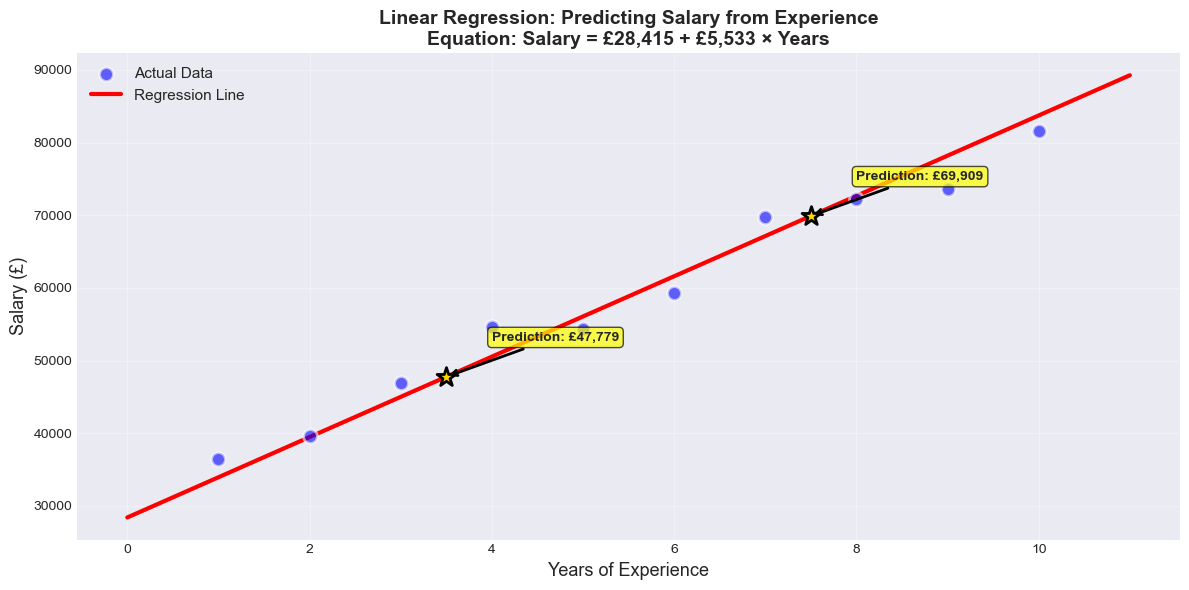


📐 Linear Regression finds the best-fit line through the data!

   Equation: Salary = £28,415.13 + £5,532.55 × Years

   Interpretation:
      • Starting salary (0 years): £28,415.13
      • Salary increase per year: £5,532.55

   Example predictions:
      • 3.5 years experience → £47,779.07
      • 7.5 years experience → £69,909.29


In [20]:
# Create visualization
plt.figure(figsize=(12, 6))

# Plot data points
plt.scatter(years_experience, salary, s=100, alpha=0.6, color='blue', 
            edgecolors='white', linewidth=2, label='Actual Data', zorder=3)

# Plot regression line
x_line = np.linspace(0, 11, 100)
y_line = theta_0 + theta_1 * x_line
plt.plot(x_line, y_line, 'r-', linewidth=3, label='Regression Line', zorder=2)

# Show predictions for new points
new_experience = [3.5, 7.5]
predictions = [theta_0 + theta_1 * x for x in new_experience]

for x, y in zip(new_experience, predictions):
    plt.scatter(x, y, s=200, marker='*', color='gold', edgecolors='black', 
                linewidth=2, zorder=4)
    plt.annotate(f'Prediction: £{y:,.0f}', xy=(x, y), xytext=(x+0.5, y+5000),
                fontsize=10, fontweight='bold', 
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Formatting
plt.xlabel('Years of Experience', fontsize=13)
plt.ylabel('Salary (£)', fontsize=13)
plt.title('Linear Regression: Predicting Salary from Experience\n' + 
          f'Equation: Salary = £{theta_0:,.0f} + £{theta_1:,.0f} × Years', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📐 Linear Regression finds the best-fit line through the data!")
print(f"\n   Equation: Salary = £{theta_0:,.2f} + £{theta_1:,.2f} × Years")
print(f"\n   Interpretation:")
print(f"      • Starting salary (0 years): £{theta_0:,.2f}")
print(f"      • Salary increase per year: £{theta_1:,.2f}")
print(f"\n   Example predictions:")
for x, y in zip(new_experience, predictions):
    print(f"      • {x} years experience → £{y:,.2f}")

## 3. Mathematical Foundation <a id="3"></a>

### How Does Linear Regression Learn?

The algorithm learns by finding the values of $\theta_0$ and $\theta_1$ that **minimize the error** between predictions and actual values.

### 1. Making Predictions

For each data point $i$, we predict:

$$\hat{y}_i = \theta_0 + \theta_1 x_i$$

### 2. Measuring Error

The **error** (residual) for each point:

$$\text{error}_i = y_i - \hat{y}_i$$

### 3. Cost Function (Mean Squared Error)

We want to minimize the **average of squared errors**:

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2$$

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (\theta_0 + \theta_1 x_i - y_i)^2$$

Where:
- $m$ = number of training examples
- We square errors to make them positive and penalize large errors more

**Goal**: Find $\theta_0$ and $\theta_1$ that minimize $J$

### 4. Finding the Solution

Two main approaches:

#### **A. Analytical Solution (Normal Equation)**

For simple linear regression:

$$\theta_1 = \frac{\sum_{i=1}^{m}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{m}(x_i - \bar{x})^2}$$

$$\theta_0 = \bar{y} - \theta_1 \bar{x}$$

Where $\bar{x}$ and $\bar{y}$ are the means of x and y.

#### **B. Iterative Solution (Gradient Descent)**

Start with random $\theta$ values, then repeatedly update:

$$\theta_0 := \theta_0 - \alpha \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)$$

$$\theta_1 := \theta_1 - \alpha \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i) \cdot x_i$$

Where $\alpha$ is the **learning rate** (step size).

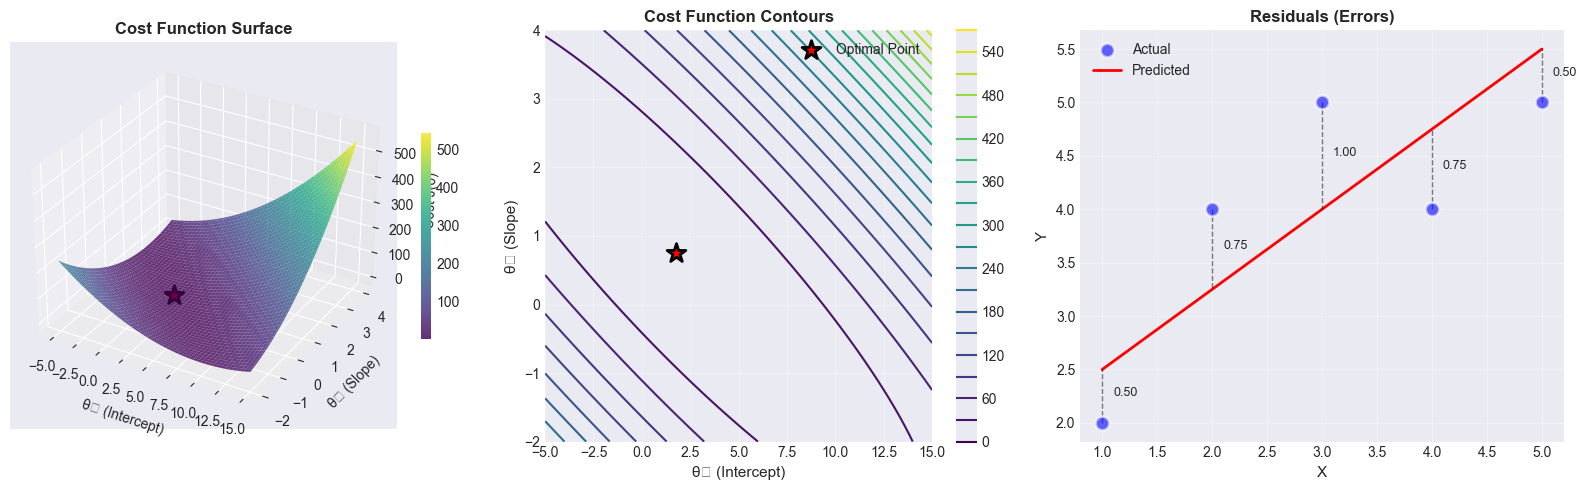


📊 Understanding the Cost Function:

   Optimal parameters found:
      θ₀ (intercept) = 1.750
      θ₁ (slope) = 0.750

   💡 The algorithm searches for the values that minimize cost (lowest point on surface)
   💡 Residuals show the difference between actual and predicted values


In [5]:
# Visualize the Cost Function

# Generate simple data
X_simple = np.array([1, 2, 3, 4, 5])
y_simple = np.array([2, 4, 5, 4, 5])

# Create a grid of theta values
theta0_vals = np.linspace(-5, 15, 100)
theta1_vals = np.linspace(-2, 4, 100)
cost_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

# Calculate cost for each combination
for i, theta0 in enumerate(theta0_vals):
    for j, theta1 in enumerate(theta1_vals):
        predictions = theta0 + theta1 * X_simple
        cost_vals[i, j] = np.mean((predictions - y_simple) ** 2)

# Find optimal parameters
theta1_opt = np.cov(X_simple, y_simple)[0, 1] / np.var(X_simple)
theta0_opt = np.mean(y_simple) - theta1_opt * np.mean(X_simple)

# Create visualization
fig = plt.figure(figsize=(16, 5))

# 3D surface plot
ax1 = fig.add_subplot(131, projection='3d')
THETA0, THETA1 = np.meshgrid(theta0_vals, theta1_vals)
surf = ax1.plot_surface(THETA0, THETA1, cost_vals.T, cmap='viridis', alpha=0.8)
ax1.scatter([theta0_opt], [theta1_opt], [np.mean((theta0_opt + theta1_opt * X_simple - y_simple) ** 2)],
           color='red', s=200, marker='*', edgecolors='black', linewidth=2, label='Optimal')
ax1.set_xlabel('θ₀ (Intercept)', fontsize=10)
ax1.set_ylabel('θ₁ (Slope)', fontsize=10)
ax1.set_zlabel('Cost J(θ)', fontsize=10)
ax1.set_title('Cost Function Surface', fontsize=12, fontweight='bold')
plt.colorbar(surf, ax=ax1, shrink=0.5)

# Contour plot
ax2 = fig.add_subplot(132)
contour = ax2.contour(THETA0, THETA1, cost_vals.T, levels=20, cmap='viridis')
ax2.scatter(theta0_opt, theta1_opt, color='red', s=200, marker='*', 
           edgecolors='black', linewidth=2, label='Optimal Point', zorder=5)
ax2.set_xlabel('θ₀ (Intercept)', fontsize=11)
ax2.set_ylabel('θ₁ (Slope)', fontsize=11)
ax2.set_title('Cost Function Contours', fontsize=12, fontweight='bold')
ax2.legend()
plt.colorbar(contour, ax=ax2)
ax2.grid(True, alpha=0.3)

# Error visualization
ax3 = fig.add_subplot(133)
y_pred = theta0_opt + theta1_opt * X_simple
ax3.scatter(X_simple, y_simple, s=100, alpha=0.6, color='blue', 
           edgecolors='white', linewidth=2, label='Actual', zorder=3)
ax3.plot(X_simple, y_pred, 'r-', linewidth=2, label='Predicted', zorder=2)

# Show residuals (errors)
for x, y_true, y_p in zip(X_simple, y_simple, y_pred):
    ax3.plot([x, x], [y_true, y_p], 'k--', alpha=0.5, linewidth=1)
    ax3.text(x+0.1, (y_true+y_p)/2, f'{abs(y_true-y_p):.2f}', fontsize=9)

ax3.set_xlabel('X', fontsize=11)
ax3.set_ylabel('Y', fontsize=11)
ax3.set_title('Residuals (Errors)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Understanding the Cost Function:")
print(f"\n   Optimal parameters found:")
print(f"      θ₀ (intercept) = {theta0_opt:.3f}")
print(f"      θ₁ (slope) = {theta1_opt:.3f}")
print(f"\n   💡 The algorithm searches for the values that minimize cost (lowest point on surface)")
print(f"   💡 Residuals show the difference between actual and predicted values")

## 4. Simple Linear Regression - Theory <a id="4"></a>

### Algorithm Steps

**Input:** Training data $(x_1, y_1), (x_2, y_2), ..., (x_m, y_m)$

**Output:** Parameters $\theta_0$ and $\theta_1$

**Algorithm:**

```
1. Calculate means: x̄ and ȳ

2. Calculate slope:
   θ₁ = Σ(xᵢ - x̄)(yᵢ - ȳ) / Σ(xᵢ - x̄)²

3. Calculate intercept:
   θ₀ = ȳ - θ₁ × x̄

4. Make predictions:
   ŷ = θ₀ + θ₁ × x
```

### Why This Works

This formula (called the **Least Squares Method**) gives us the line that:
- Minimizes the sum of squared errors
- Has the best overall fit to the data
- Is the mathematical optimum (proven by calculus!)

## 5. Implementation from Scratch <a id="5"></a>

Let's implement Linear Regression from scratch to understand how it really works!

In [6]:
class SimpleLinearRegression:
    """
    Simple Linear Regression implementation from scratch.
    
    Implements: y = θ₀ + θ₁x
    """
    
    def __init__(self):
        self.theta_0 = None  # Intercept
        self.theta_1 = None  # Slope
        
    def fit(self, X, y):
        """
        Fit the linear regression model using the Normal Equation.
        
        Parameters:
        -----------
        X : array-like, shape (n_samples,)
            Training data (features)
        y : array-like, shape (n_samples,)
            Target values
        """
        # Convert to numpy arrays
        X = np.array(X)
        y = np.array(y)
        
        # Calculate means
        x_mean = np.mean(X)
        y_mean = np.mean(y)
        
        # Calculate slope (theta_1)
        numerator = np.sum((X - x_mean) * (y - y_mean))
        denominator = np.sum((X - x_mean) ** 2)
        self.theta_1 = numerator / denominator
        
        # Calculate intercept (theta_0)
        self.theta_0 = y_mean - self.theta_1 * x_mean
        
        print(f"✅ Model trained successfully!")
        print(f"   θ₀ (intercept) = {self.theta_0:.4f}")
        print(f"   θ₁ (slope) = {self.theta_1:.4f}")
        
        return self
    
    def predict(self, X):
        """
        Make predictions using the linear model.
        
        Parameters:
        -----------
        X : array-like, shape (n_samples,)
            Input data
            
        Returns:
        --------
        y_pred : array, shape (n_samples,)
            Predicted values
        """
        if self.theta_0 is None or self.theta_1 is None:
            raise Exception("Model not trained. Call fit() first.")
        
        X = np.array(X)
        return self.theta_0 + self.theta_1 * X
    
    def score(self, X, y):
        """
        Calculate R² score (coefficient of determination).
        
        R² = 1 - (SS_res / SS_tot)
        where SS_res = Σ(y - ŷ)² and SS_tot = Σ(y - ȳ)²
        
        Returns value between 0 and 1 (1 = perfect fit)
        """
        y = np.array(y)
        y_pred = self.predict(X)
        
        ss_res = np.sum((y - y_pred) ** 2)  # Residual sum of squares
        ss_tot = np.sum((y - np.mean(y)) ** 2)  # Total sum of squares
        
        r2 = 1 - (ss_res / ss_tot)
        return r2

print("✅ SimpleLinearRegression class created!")
print("\nFeatures:")
print("  • fit(X, y) - Train the model")
print("  • predict(X) - Make predictions")
print("  • score(X, y) - Calculate R² score")

✅ SimpleLinearRegression class created!

Features:
  • fit(X, y) - Train the model
  • predict(X) - Make predictions
  • score(X, y) - Calculate R² score


✅ Model trained successfully!
   θ₀ (intercept) = 3.4860
   θ₁ (slope) = 1.9931

📊 R² Score: 0.9859
   (1.0 = perfect fit, 0.0 = no better than average)


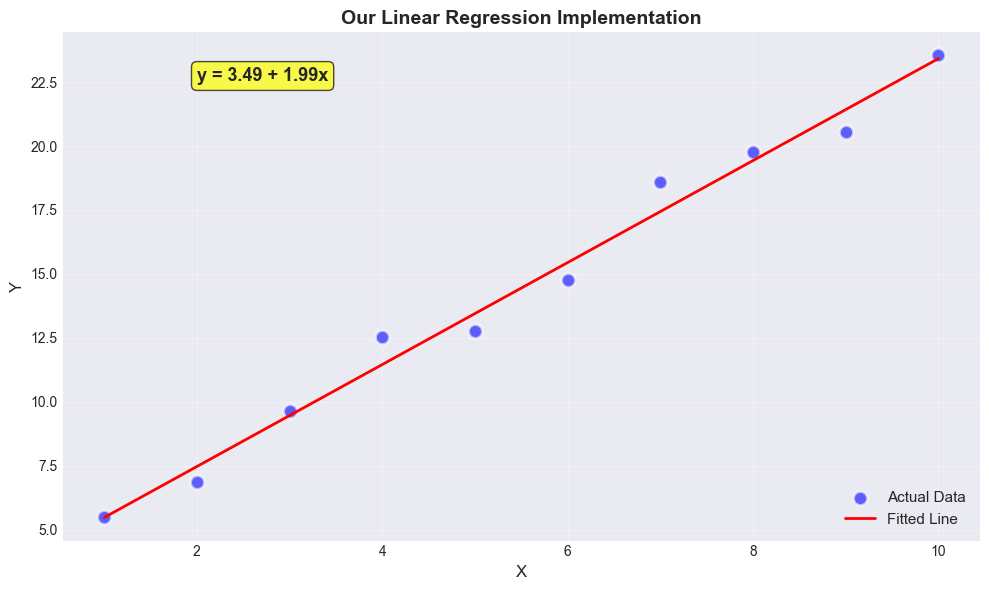


🎉 Our implementation works perfectly!


In [7]:
# Test our implementation

# Generate sample data
np.random.seed(42)
X_test = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_test = 3 + 2 * X_test + np.random.normal(0, 1, 10)

# Create and train model
model = SimpleLinearRegression()
model.fit(X_test, y_test)

# Make predictions
y_pred = model.predict(X_test)

# Calculate R² score
r2 = model.score(X_test, y_test)
print(f"\n📊 R² Score: {r2:.4f}")
print("   (1.0 = perfect fit, 0.0 = no better than average)")

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, s=100, alpha=0.6, color='blue', 
            edgecolors='white', linewidth=2, label='Actual Data')
plt.plot(X_test, y_pred, 'r-', linewidth=2, label='Fitted Line')

# Show equation
equation = f'y = {model.theta_0:.2f} + {model.theta_1:.2f}x'
plt.text(2, max(y_test)-1, equation, fontsize=13, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('Our Linear Regression Implementation', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🎉 Our implementation works perfectly!")

## 6. Example 1: Salary Prediction <a id="6"></a>

Let's apply Linear Regression to a realistic problem: **Predicting salary based on years of experience**.

### Business Context

A company wants to:
- Predict fair salaries for new hires
- Understand the relationship between experience and pay
- Make data-driven compensation decisions

In [8]:
# Create realistic salary dataset

np.random.seed(42)

# Generate data for 50 employees
n_employees = 50
years_experience = np.random.uniform(0, 15, n_employees)

# Base salary + experience component + random variation
# Realistic formula: Salary increases by ~$4,000 per year
base_salary = 35000
salary_per_year = 4000
salary = base_salary + salary_per_year * years_experience + np.random.normal(0, 5000, n_employees)

# Create DataFrame
salary_data = pd.DataFrame({
    'Years_Experience': years_experience,
    'Salary': salary
})

# Sort by experience for better visualization
salary_data = salary_data.sort_values('Years_Experience').reset_index(drop=True)

print("💼 Employee Salary Dataset")
print("\nDataset Preview:")
print(salary_data.head(10))
print(f"\nDataset shape: {salary_data.shape}")
print("\nBasic Statistics:")
print(salary_data.describe())

💼 Employee Salary Dataset

Dataset Preview:
   Years_Experience        Salary
0          0.308767  37855.489505
1          0.515828  44452.781491
2          0.696756  34561.425990
3          0.871254  36181.822875
4          0.975774  38723.965384
5          1.465082  39365.290088
6          1.830574  41223.934651
7          2.092408  42441.336756
8          2.339918  40760.450178
9          2.340280  36968.508475

Dataset shape: (50, 2)

Basic Statistics:
       Years_Experience        Salary
count         50.000000     50.000000
mean           6.688859  61740.707836
std            4.333248  17616.630562
min            0.308767  34561.425990
25%            2.756505  47412.154156
50%            6.540731  61868.879153
75%            9.747824  72677.007679
max           14.548648  99756.350514


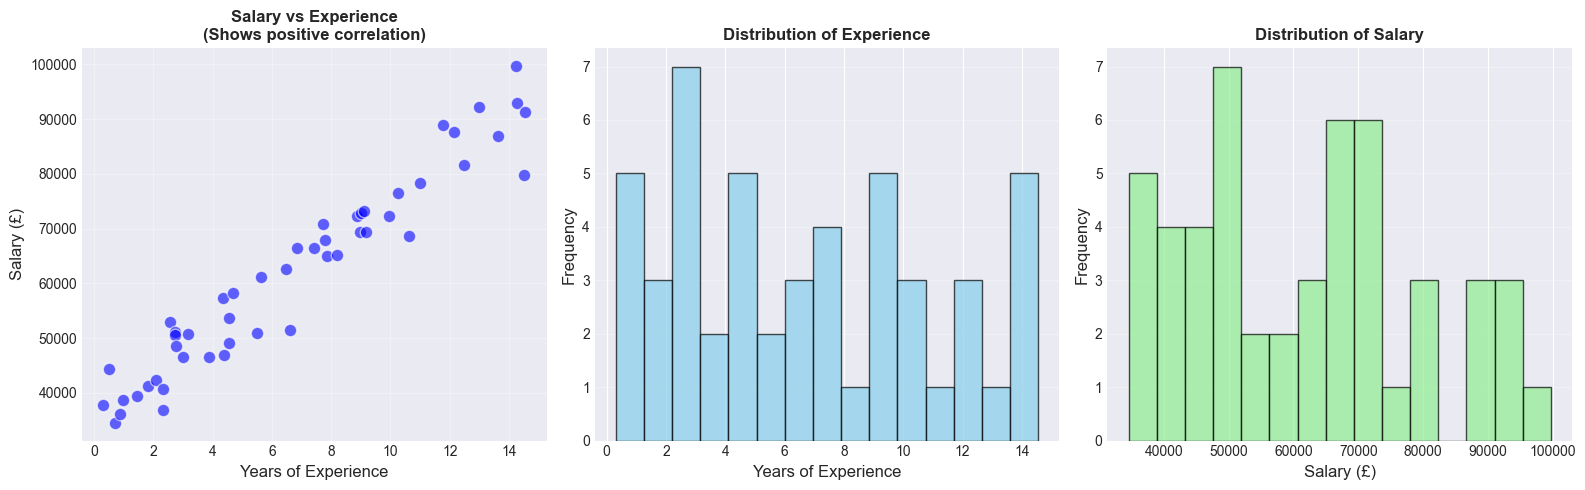


📊 Correlation between Experience and Salary: 0.966
   (Close to 1.0 indicates strong positive relationship - perfect for linear regression!)


In [9]:
# Exploratory Data Analysis (EDA)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Scatter plot
axes[0].scatter(salary_data['Years_Experience'], salary_data['Salary'], 
                alpha=0.6, s=80, color='blue', edgecolors='white', linewidth=1)
axes[0].set_xlabel('Years of Experience', fontsize=12)
axes[0].set_ylabel('Salary (£)', fontsize=12)
axes[0].set_title('Salary vs Experience\n(Shows positive correlation)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 2. Distribution of Years
axes[1].hist(salary_data['Years_Experience'], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Years of Experience', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Experience', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Distribution of Salary
axes[2].hist(salary_data['Salary'], bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Salary (£)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].set_title('Distribution of Salary', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Calculate correlation
correlation = salary_data['Years_Experience'].corr(salary_data['Salary'])
print(f"\n📊 Correlation between Experience and Salary: {correlation:.3f}")
print("   (Close to 1.0 indicates strong positive relationship - perfect for linear regression!)")

In [10]:
# Train Linear Regression Model

print("🎯 Training Linear Regression Model...\n")

# Split data into features (X) and target (y)
X = salary_data['Years_Experience'].values
y = salary_data['Salary'].values

# Split into training and testing sets (80-20 split)
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples\n")

# Train model using our custom implementation
salary_model = SimpleLinearRegression()
salary_model.fit(X_train, y_train)

# Make predictions on test set
y_pred = salary_model.predict(X_test)

# Evaluate model
r2_train = salary_model.score(X_train, y_train)
r2_test = salary_model.score(X_test, y_test)

print(f"\n📈 Model Performance:")
print(f"   Training R²: {r2_train:.4f}")
print(f"   Testing R²: {r2_test:.4f}")
print(f"\n💡 Interpretation:")
print(f"   Starting salary (0 years): ${salary_model.theta_0:,.2f}")
print(f"   Salary increase per year: ${salary_model.theta_1:,.2f}")

🎯 Training Linear Regression Model...

Training set: 40 samples
Testing set: 10 samples

✅ Model trained successfully!
   θ₀ (intercept) = 35870.2062
   θ₁ (slope) = 3808.6738

📈 Model Performance:
   Training R²: 0.8920
   Testing R²: 0.0460

💡 Interpretation:
   Starting salary (0 years): $35,870.21
   Salary increase per year: $3,808.67


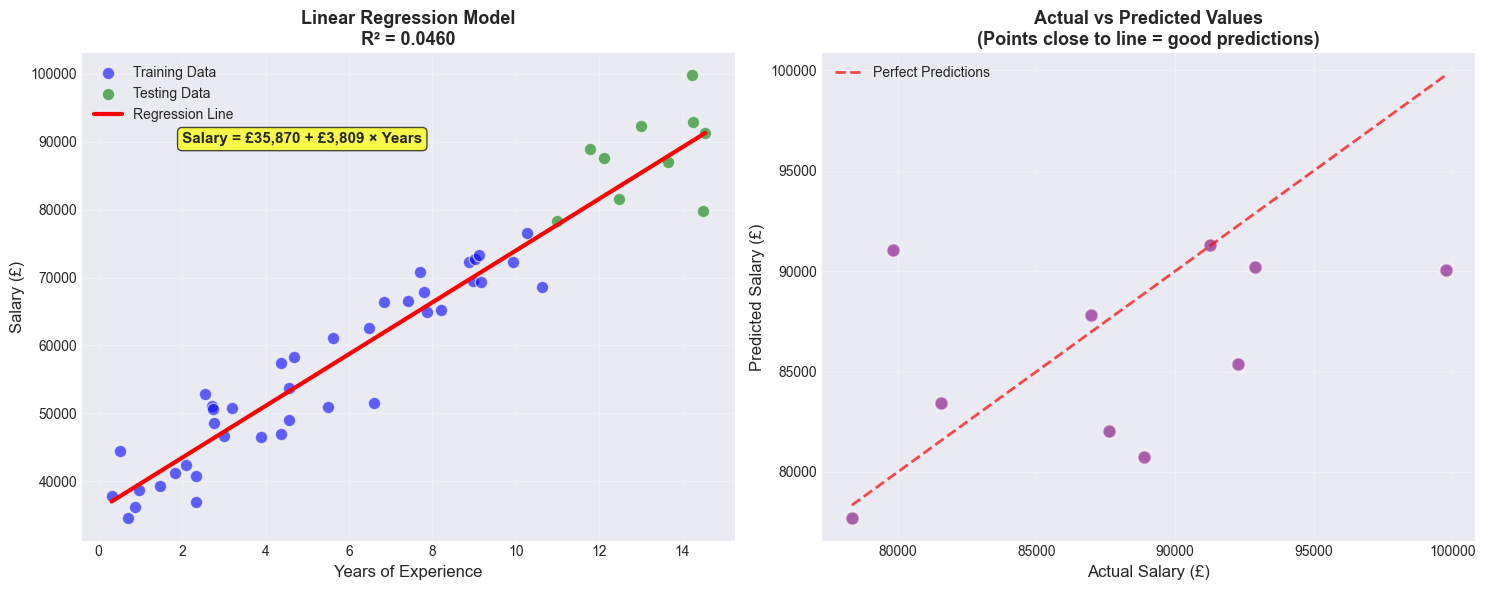


✅ Model successfully predicts salaries based on experience!


In [11]:
# Visualize Results

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Fitted line on all data
axes[0].scatter(X_train, y_train, alpha=0.6, s=80, color='blue', 
                edgecolors='white', linewidth=1, label='Training Data')
axes[0].scatter(X_test, y_test, alpha=0.6, s=80, color='green', 
                edgecolors='white', linewidth=1, label='Testing Data')

# Plot regression line
x_line = np.linspace(X.min(), X.max(), 100)
y_line = salary_model.predict(x_line)
axes[0].plot(x_line, y_line, 'r-', linewidth=3, label='Regression Line')

# Add equation
equation = f'Salary = £{salary_model.theta_0:,.0f} + £{salary_model.theta_1:,.0f} × Years'
axes[0].text(2, max(y)*0.9, equation, fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

axes[0].set_xlabel('Years of Experience', fontsize=12)
axes[0].set_ylabel('Salary (£)', fontsize=12)
axes[0].set_title(f'Linear Regression Model\nR² = {r2_test:.4f}', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 2. Actual vs Predicted
axes[1].scatter(y_test, y_pred, alpha=0.6, s=100, color='purple', 
                edgecolors='white', linewidth=1.5)

# Perfect prediction line
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
axes[1].plot(perfect_line, perfect_line, 'r--', linewidth=2, 
             label='Perfect Predictions', alpha=0.7)

axes[1].set_xlabel('Actual Salary (£)', fontsize=12)
axes[1].set_ylabel('Predicted Salary (£)', fontsize=12)
axes[1].set_title('Actual vs Predicted Values\n(Points close to line = good predictions)', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Model successfully predicts salaries based on experience!")

🎯 Salary Predictions for New Hires:

Years of Experience:  0 → Predicted Salary: £35,870.21
Years of Experience:  2 → Predicted Salary: £43,487.55
Years of Experience:  5 → Predicted Salary: £54,913.58
Years of Experience:  7 → Predicted Salary: £62,530.92
Years of Experience: 10 → Predicted Salary: £73,956.94
Years of Experience: 12 → Predicted Salary: £81,574.29
Years of Experience: 15 → Predicted Salary: £93,000.31


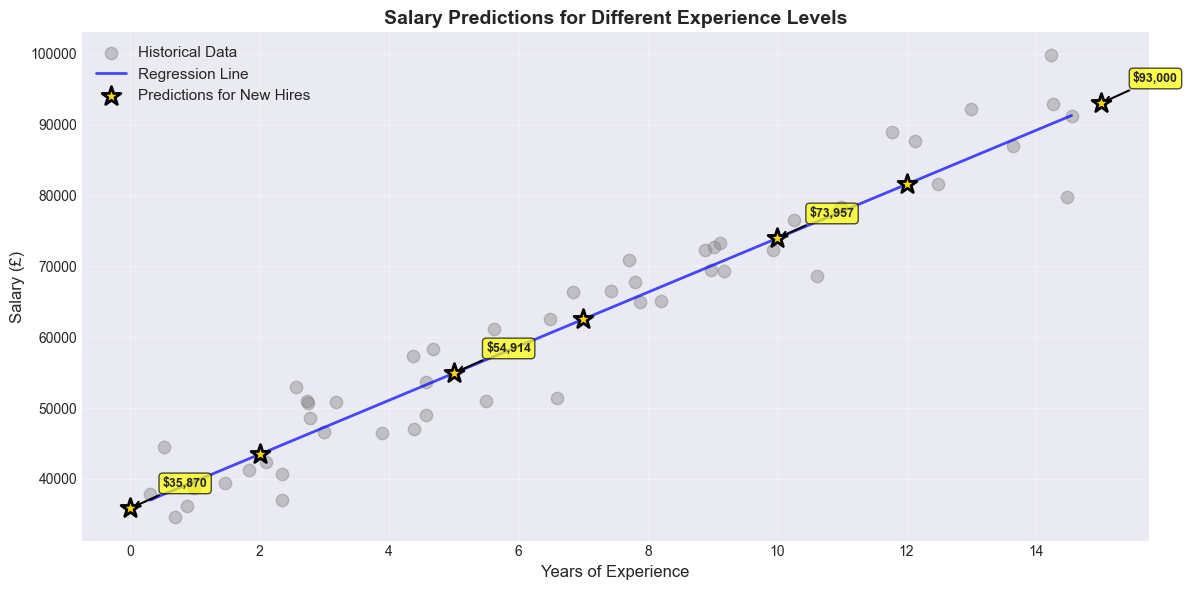


💼 These predictions can help with:
   • Setting competitive salary offers
   • Budgeting for new positions
   • Ensuring fair compensation across experience levels


In [12]:
# Make predictions for new employees

print("🎯 Salary Predictions for New Hires:\n")
print("="*60)

# Predict for different experience levels
new_experience_levels = [0, 2, 5, 7, 10, 12, 15]

for years in new_experience_levels:
    predicted_salary = salary_model.predict([years])[0]
    print(f"Years of Experience: {years:2d} → Predicted Salary: £{predicted_salary:,.2f}")

print("="*60)

# Visualize predictions
predicted_salaries = salary_model.predict(new_experience_levels)

plt.figure(figsize=(12, 6))
plt.scatter(X, y, alpha=0.4, s=80, color='gray', label='Historical Data')
plt.plot(x_line, y_line, 'b-', linewidth=2, label='Regression Line', alpha=0.7)
plt.scatter(new_experience_levels, predicted_salaries, s=200, marker='*', 
            color='gold', edgecolors='black', linewidth=2, 
            label='Predictions for New Hires', zorder=5)

# Add labels to predictions
for years, salary in zip(new_experience_levels[::2], predicted_salaries[::2]):
    plt.annotate(f'${salary:,.0f}', xy=(years, salary), 
                xytext=(years+0.5, salary+3000),
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary (£)', fontsize=12)
plt.title('Salary Predictions for Different Experience Levels', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💼 These predictions can help with:")
print("   • Setting competitive salary offers")
print("   • Budgeting for new positions")
print("   • Ensuring fair compensation across experience levels")

## 7. Using Scikit-learn <a id="7"></a>

While our custom implementation is educational, **scikit-learn** provides professional, optimized implementations. Let's learn to use it!

In [14]:
# Professional implementation with scikit-learn

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

print("🔧 Using Scikit-learn for Linear Regression\n")

# Prepare data (sklearn expects 2D arrays)
X_sklearn = salary_data['Years_Experience'].values.reshape(-1, 1)
y_sklearn = salary_data['Salary'].values

# Split data (sklearn has a built-in function!)
X_train_sk, X_test_sk, y_train_sk, y_test_sk = train_test_split(
    X_sklearn, y_sklearn, test_size=0.2, random_state=42
)

print(f"Training set: {X_train_sk.shape[0]} samples")
print(f"Testing set: {X_test_sk.shape[0]} samples\n")

# Create and train model
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_sk, y_train_sk)

print("✅ Model trained!")
print(f"\nModel Parameters:")
print(f"   Intercept (θ₀): £{sklearn_model.intercept_:,.2f}")
print(f"   Coefficient (θ₁): £{sklearn_model.coef_[0]:,.2f}")

# Make predictions
y_pred_sk = sklearn_model.predict(X_test_sk)

# Evaluate
r2_train_sk = sklearn_model.score(X_train_sk, y_train_sk)
r2_test_sk = sklearn_model.score(X_test_sk, y_test_sk)

print(f"\n📊 Model Performance:")
print(f"   Training R²: {r2_train_sk:.4f}")
print(f"   Testing R²: {r2_test_sk:.4f}")

# Compare with our implementation
print(f"\n🔍 Comparison with Our Implementation:")
print(f"   Our θ₀: £{salary_model.theta_0:,.2f} | Sklearn θ₀: £{sklearn_model.intercept_:,.2f}")
print(f"   Our θ₁: £{salary_model.theta_1:,.2f} | Sklearn θ₁: £{sklearn_model.coef_[0]:,.2f}")
print(f"\n   ✅ Almost identical! Our implementation works correctly!")

🔧 Using Scikit-learn for Linear Regression

Training set: 40 samples
Testing set: 10 samples

✅ Model trained!

Model Parameters:
   Intercept (θ₀): £34,783.63
   Coefficient (θ₁): £4,137.08

📊 Model Performance:
   Training R²: 0.9574
   Testing R²: 0.6622

🔍 Comparison with Our Implementation:
   Our θ₀: £35,870.21 | Sklearn θ₀: £34,783.63
   Our θ₁: £3,808.67 | Sklearn θ₁: £4,137.08

   ✅ Almost identical! Our implementation works correctly!


### Advantages of Scikit-learn

✅ **Optimized**: Faster for large datasets

✅ **Features**: More built-in functionality

✅ **Consistent API**: Works same way across all algorithms

✅ **Well-tested**: Industry standard

✅ **Documentation**: Excellent resources

### Standard Workflow

```python
# 1. Import
from sklearn.linear_model import LinearRegression

# 2. Create model object
model = LinearRegression()

# 3. Train (fit)
model.fit(X_train, y_train)

# 4. Predict
predictions = model.predict(X_test)

# 5. Evaluate
score = model.score(X_test, y_test)
```

---

## 8. Model Evaluation Metrics <a id="8"></a>

How do we know if our model is good? We use evaluation metrics!

### Main Regression Metrics

#### 1. **R² Score (Coefficient of Determination)**

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- **Range**: 0 to 1 (can be negative for terrible models)
- **Interpretation**: Percentage of variance explained by the model
- **0.0**: Model no better than predicting the mean
- **0.5**: Model explains 50% of variance
- **1.0**: Perfect predictions

#### 2. **Mean Squared Error (MSE)**

$$MSE = \frac{1}{m} \sum_{i=1}^{m}(y_i - \hat{y}_i)^2$$

- **Range**: 0 to ∞ (lower is better)
- **Units**: Squared units of target variable
- **Interpretation**: Average squared error
- **Penalizes** large errors more (due to squaring)

#### 3. **Root Mean Squared Error (RMSE)**

$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{m} \sum_{i=1}^{m}(y_i - \hat{y}_i)^2}$$

- **Range**: 0 to ∞ (lower is better)
- **Units**: Same as target variable
- **Interpretation**: Average error magnitude
- **More interpretable** than MSE (same units as y)

#### 4. **Mean Absolute Error (MAE)**

$$MAE = \frac{1}{m} \sum_{i=1}^{m}|y_i - \hat{y}_i|$$

- **Range**: 0 to ∞ (lower is better)
- **Units**: Same as target variable
- **Interpretation**: Average absolute error
- **More robust** to outliers than MSE/RMSE

In [15]:
# Calculate all metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Get predictions
y_pred_test = sklearn_model.predict(X_test_sk)

# Calculate metrics
r2 = r2_score(y_test_sk, y_pred_test)
mse = mean_squared_error(y_test_sk, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_sk, y_pred_test)

print("📊 Model Evaluation Metrics")
print("="*60)
print(f"\n1. R² Score: {r2:.4f}")
print(f"   → Model explains {r2*100:.2f}% of variance in salary")
print(f"   → Interpretation: {'Excellent' if r2 > 0.9 else 'Good' if r2 > 0.7 else 'Moderate' if r2 > 0.5 else 'Poor'}")

print(f"\n2. Mean Squared Error (MSE): £{mse:,.2f}")
print(f"   → Average squared error")

print(f"\n3. Root Mean Squared Error (RMSE): £{rmse:,.2f}")
print(f"   → On average, predictions are off by ~£{rmse:,.0f}")
print(f"   → This is about {(rmse/y_test_sk.mean())*100:.1f}% of average salary")

print(f"\n4. Mean Absolute Error (MAE): £{mae:,.2f}")
print(f"   → Average absolute error is £{mae:,.0f}")
print(f"   → More robust to outliers than RMSE")

print("\n" + "="*60)
print("\n💡 Which metric to use?")
print("   • R²: Overall model quality (how well it fits)")
print("   • RMSE: When you want to penalize large errors")
print("   • MAE: When all errors are equally important")

📊 Model Evaluation Metrics

1. R² Score: 0.6622
   → Model explains 66.22% of variance in salary
   → Interpretation: Moderate

2. Mean Squared Error (MSE): £51,789,483.74
   → Average squared error

3. Root Mean Squared Error (RMSE): £7,196.49
   → On average, predictions are off by ~£7,196
   → This is about 11.1% of average salary

4. Mean Absolute Error (MAE): £5,785.33
   → Average absolute error is £5,785
   → More robust to outliers than RMSE


💡 Which metric to use?
   • R²: Overall model quality (how well it fits)
   • RMSE: When you want to penalize large errors
   • MAE: When all errors are equally important


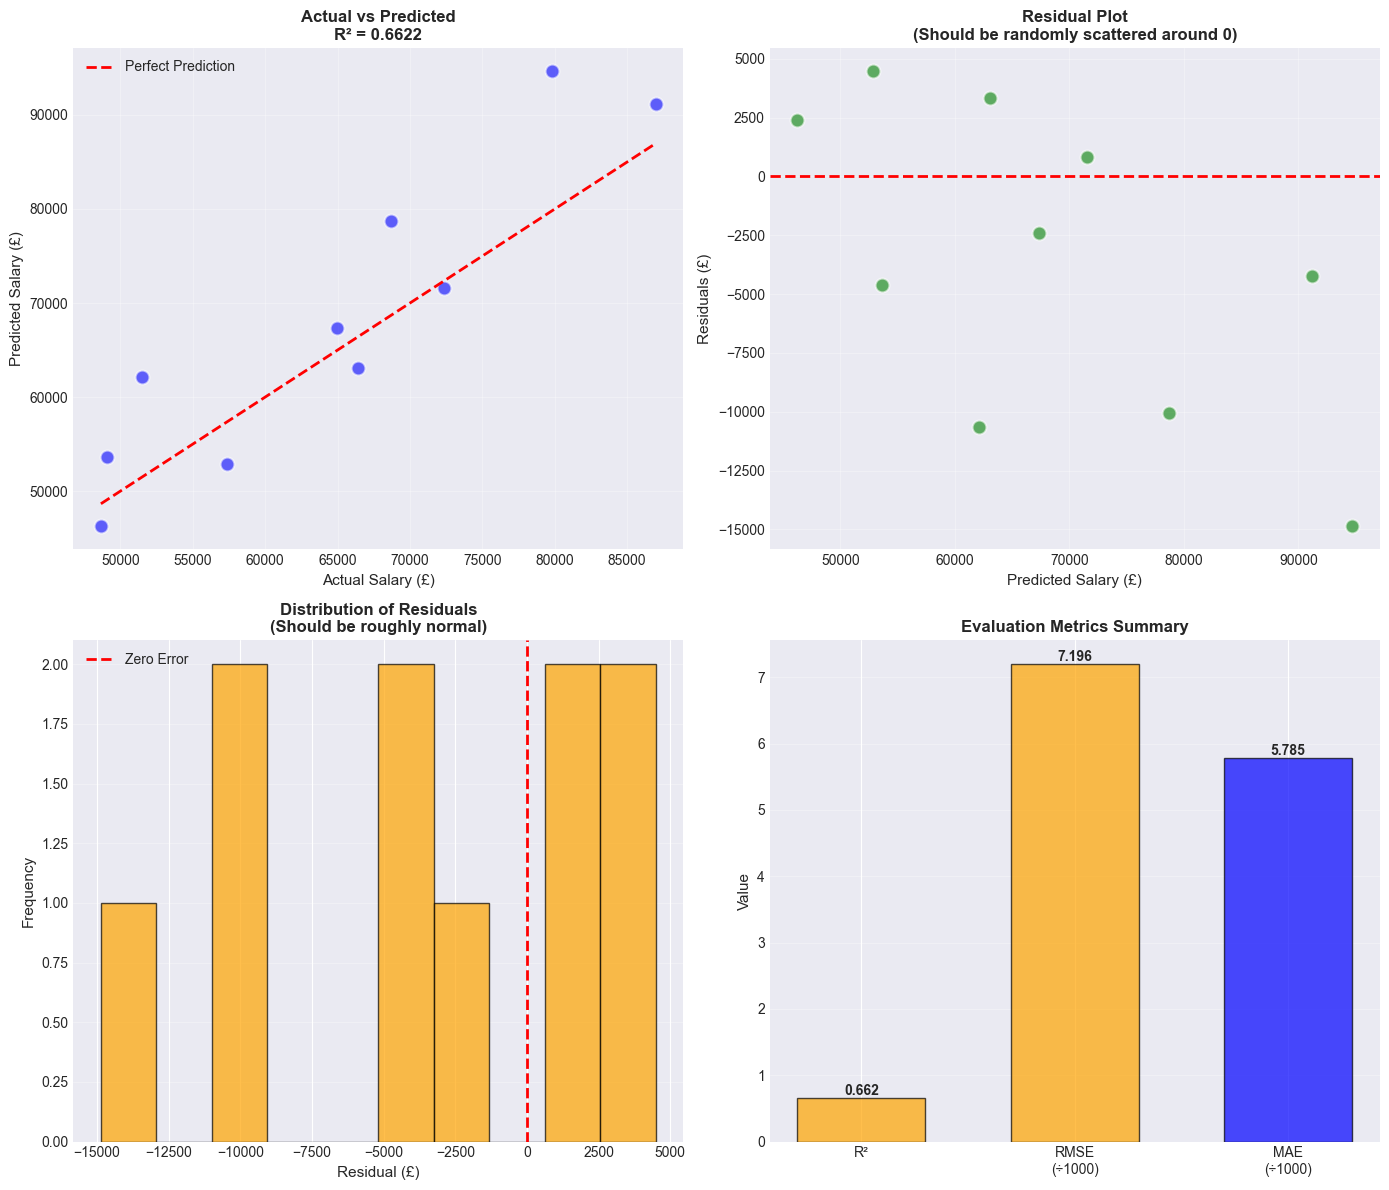


📊 What these plots tell us:

1. Actual vs Predicted: Points should be close to the red line
2. Residual Plot: Points should be randomly scattered (no pattern)
3. Residual Distribution: Should look roughly bell-shaped (normal)
4. Metrics: Higher R² is better; Lower RMSE/MAE is better

✅ Our model shows good performance across all metrics!


In [16]:
# Visualize model performance

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test_sk, y_pred_test, alpha=0.6, s=100, color='blue', 
                   edgecolors='white', linewidth=1.5)
perfect_line = np.linspace(y_test_sk.min(), y_test_sk.max(), 100)
axes[0, 0].plot(perfect_line, perfect_line, 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Salary (£)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Salary (£)', fontsize=11)
axes[0, 0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residual Plot
residuals = y_test_sk - y_pred_test
axes[0, 1].scatter(y_pred_test, residuals, alpha=0.6, s=100, color='green', 
                   edgecolors='white', linewidth=1.5)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Salary (£)', fontsize=11)
axes[0, 1].set_ylabel('Residuals (£)', fontsize=11)
axes[0, 1].set_title('Residual Plot\n(Should be randomly scattered around 0)', 
                     fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of Residuals
axes[1, 0].hist(residuals, bins=10, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1, 0].set_xlabel('Residual (£)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Distribution of Residuals\n(Should be roughly normal)', 
                     fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Error Metrics Comparison
metrics_names = ['R²', 'RMSE\n(÷1000)', 'MAE\n(÷1000)']
metrics_values = [r2, rmse/1000, mae/1000]
colors_bar = ['green' if r2 > 0.7 else 'orange', 'orange', 'blue']

bars = axes[1, 1].bar(metrics_names, metrics_values, color=colors_bar, 
                      edgecolor='black', alpha=0.7, width=0.6)
axes[1, 1].set_ylabel('Value', fontsize=11)
axes[1, 1].set_title('Evaluation Metrics Summary', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 What these plots tell us:")
print("\n1. Actual vs Predicted: Points should be close to the red line")
print("2. Residual Plot: Points should be randomly scattered (no pattern)")
print("3. Residual Distribution: Should look roughly bell-shaped (normal)")
print("4. Metrics: Higher R² is better; Lower RMSE/MAE is better")
print("\n✅ Our model shows good performance across all metrics!")

---

## 9. Example 2: House Price Prediction <a id="9"></a>

Let's tackle a more complex example: **Predicting house prices with multiple features**.

This introduces us to **Multiple Linear Regression**!

In [17]:
# Create realistic house price dataset

np.random.seed(42)
n_houses = 200

# Generate features
house_data = pd.DataFrame({
    'Size_sqft': np.random.uniform(800, 3500, n_houses),
    'Bedrooms': np.random.randint(1, 6, n_houses),
    'Age_years': np.random.uniform(0, 50, n_houses),
    'Distance_to_city_km': np.random.uniform(1, 30, n_houses)
})

# Generate price based on features (realistic relationship)
# Price = base + (size effect) + (bedroom effect) - (age effect) - (distance effect) + noise
base_price = 100000
price = (base_price + 
         150 * house_data['Size_sqft'] +  # $150 per sqft
         20000 * house_data['Bedrooms'] +  # $20k per bedroom
         -2000 * house_data['Age_years'] +  # -$2k per year old
         -3000 * house_data['Distance_to_city_km'] +  # -$3k per km from city
         np.random.normal(0, 30000, n_houses))  # Random variation

house_data['Price'] = price

print("🏠 House Price Dataset")
print("\nDataset Preview:")
print(house_data.head(10))
print(f"\nDataset shape: {house_data.shape}")
print("\nBasic Statistics:")
print(house_data.describe())

🏠 House Price Dataset

Dataset Preview:
     Size_sqft  Bedrooms  Age_years  Distance_to_city_km          Price
0  1811.258321         4  48.059528            12.375077  332813.854600
1  3366.928627         3  45.267532            13.686773  543453.774843
2  2776.383643         1   9.789557            27.220602  466342.824861
3  2416.377907         4   3.468065            11.099409  486921.838416
4  1221.250329         4   5.038900            15.905695  297296.415626
5  1221.185205         3   0.911091            23.725937  240814.874589
6   956.825753         1   4.722148            12.499741  203251.546988
7  3138.675594         3  34.150339            19.040514  516698.133569
8  2423.010532         1   3.559432            26.008548  421016.730748
9  2711.795960         5  15.948782            28.536098  461598.576994

Dataset shape: (200, 5)

Basic Statistics:
         Size_sqft    Bedrooms   Age_years  Distance_to_city_km          Price
count   200.000000  200.000000  200.000000   

📊 Feature Correlations with Price:

Price                  1.000000
Size_sqft              0.898853
Bedrooms               0.102516
Distance_to_city_km   -0.053389
Age_years             -0.243970
Name: Price, dtype: float64


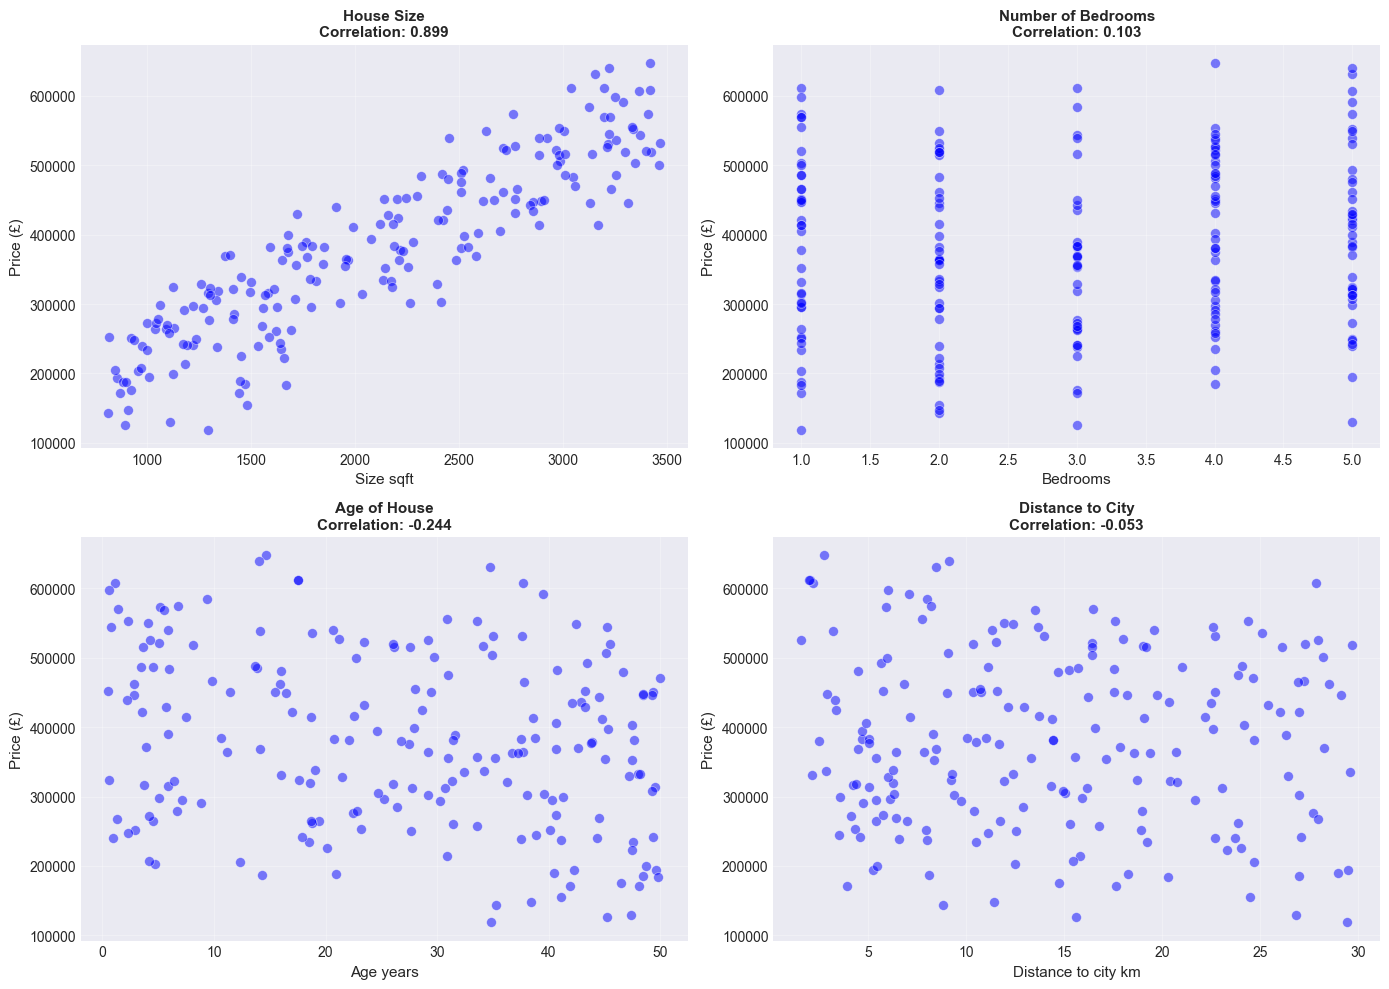


💡 Observations:
   ✅ Size has strong POSITIVE correlation (bigger = more expensive)
   ✅ Bedrooms has POSITIVE correlation (more bedrooms = higher price)
   ❌ Age has NEGATIVE correlation (older = less expensive)
   ❌ Distance has NEGATIVE correlation (farther = less expensive)


In [18]:
# Exploratory Data Analysis

# Calculate correlations with price
correlations = house_data.corr()['Price'].sort_values(ascending=False)
print("📊 Feature Correlations with Price:\n")
print(correlations)

# Visualize relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

features = ['Size_sqft', 'Bedrooms', 'Age_years', 'Distance_to_city_km']
titles = ['House Size', 'Number of Bedrooms', 'Age of House', 'Distance to City']

for idx, (feature, title) in enumerate(zip(features, titles)):
    axes[idx].scatter(house_data[feature], house_data['Price'], 
                     alpha=0.5, s=50, color='blue', edgecolors='white', linewidth=0.5)
    axes[idx].set_xlabel(feature.replace('_', ' '), fontsize=11)
    axes[idx].set_ylabel('Price (£)', fontsize=11)
    corr = house_data[feature].corr(house_data['Price'])
    axes[idx].set_title(f'{title}\nCorrelation: {corr:.3f}', 
                       fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Observations:")
print("   ✅ Size has strong POSITIVE correlation (bigger = more expensive)")
print("   ✅ Bedrooms has POSITIVE correlation (more bedrooms = higher price)")
print("   ❌ Age has NEGATIVE correlation (older = less expensive)")
print("   ❌ Distance has NEGATIVE correlation (farther = less expensive)")

## 10. Multiple Linear Regression <a id="10"></a>

When we have **multiple input features**, we use **Multiple Linear Regression**:

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_3 + ... + \theta_n x_n$$

For our house price example:

$$\text{Price} = \theta_0 + \theta_1 \times \text{Size} + \theta_2 \times \text{Bedrooms} + \theta_3 \times \text{Age} + \theta_4 \times \text{Distance}$$

Each $\theta$ coefficient tells us:
- How much the price changes when that feature increases by 1 unit
- **Holding all other features constant**

In [19]:
# Train Multiple Linear Regression

print("🎯 Training Multiple Linear Regression Model...\n")

# Prepare features and target
X_house = house_data[['Size_sqft', 'Bedrooms', 'Age_years', 'Distance_to_city_km']].values
y_house = house_data['Price'].values

# Split data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)

print(f"Training set: {X_train_h.shape[0]} houses")
print(f"Testing set: {X_test_h.shape[0]} houses")
print(f"Features: {X_train_h.shape[1]}\n")

# Train model
house_model = LinearRegression()
house_model.fit(X_train_h, y_train_h)

print("✅ Model trained successfully!\n")

# Display model equation
print("📐 Model Equation:")
print(f"\nPrice = £{house_model.intercept_:,.2f}")
feature_names = ['Size_sqft', 'Bedrooms', 'Age_years', 'Distance_to_city_km']
for name, coef in zip(feature_names, house_model.coef_):
    sign = '+' if coef >= 0 else '-'
    print(f"        {sign} £{abs(coef):,.2f} × {name}")

print("\n💡 Coefficient Interpretation:")
print(f"   • Each additional sqft adds ${house_model.coef_[0]:,.2f} to price")
print(f"   • Each additional bedroom adds £{house_model.coef_[1]:,.2f} to price")
print(f"   • Each year of age reduces price by £{abs(house_model.coef_[2]):,.2f}")
print(f"   • Each km from city reduces price by £{abs(house_model.coef_[3]):,.2f}")

# Evaluate
y_pred_h = house_model.predict(X_test_h)
r2_h = r2_score(y_test_h, y_pred_h)
rmse_h = np.sqrt(mean_squared_error(y_test_h, y_pred_h))
mae_h = mean_absolute_error(y_test_h, y_pred_h)

print(f"\n📊 Model Performance:")
print(f"   R² Score: {r2_h:.4f} ({r2_h*100:.2f}% of variance explained)")
print(f"   RMSE: £{rmse_h:,.2f}")
print(f"   MAE: £{mae_h:,.2f}")

🎯 Training Multiple Linear Regression Model...

Training set: 160 houses
Testing set: 40 houses
Features: 4

✅ Model trained successfully!

📐 Model Equation:

Price = £114,932.75
        + £146.44 × Size_sqft
        + £18,003.79 × Bedrooms
        - £1,822.10 × Age_years
        - £3,386.57 × Distance_to_city_km

💡 Coefficient Interpretation:
   • Each additional sqft adds $146.44 to price
   • Each additional bedroom adds £18,003.79 to price
   • Each year of age reduces price by £1,822.10
   • Each km from city reduces price by £3,386.57

📊 Model Performance:
   R² Score: 0.9371 (93.71% of variance explained)
   RMSE: £31,995.07
   MAE: £22,936.16


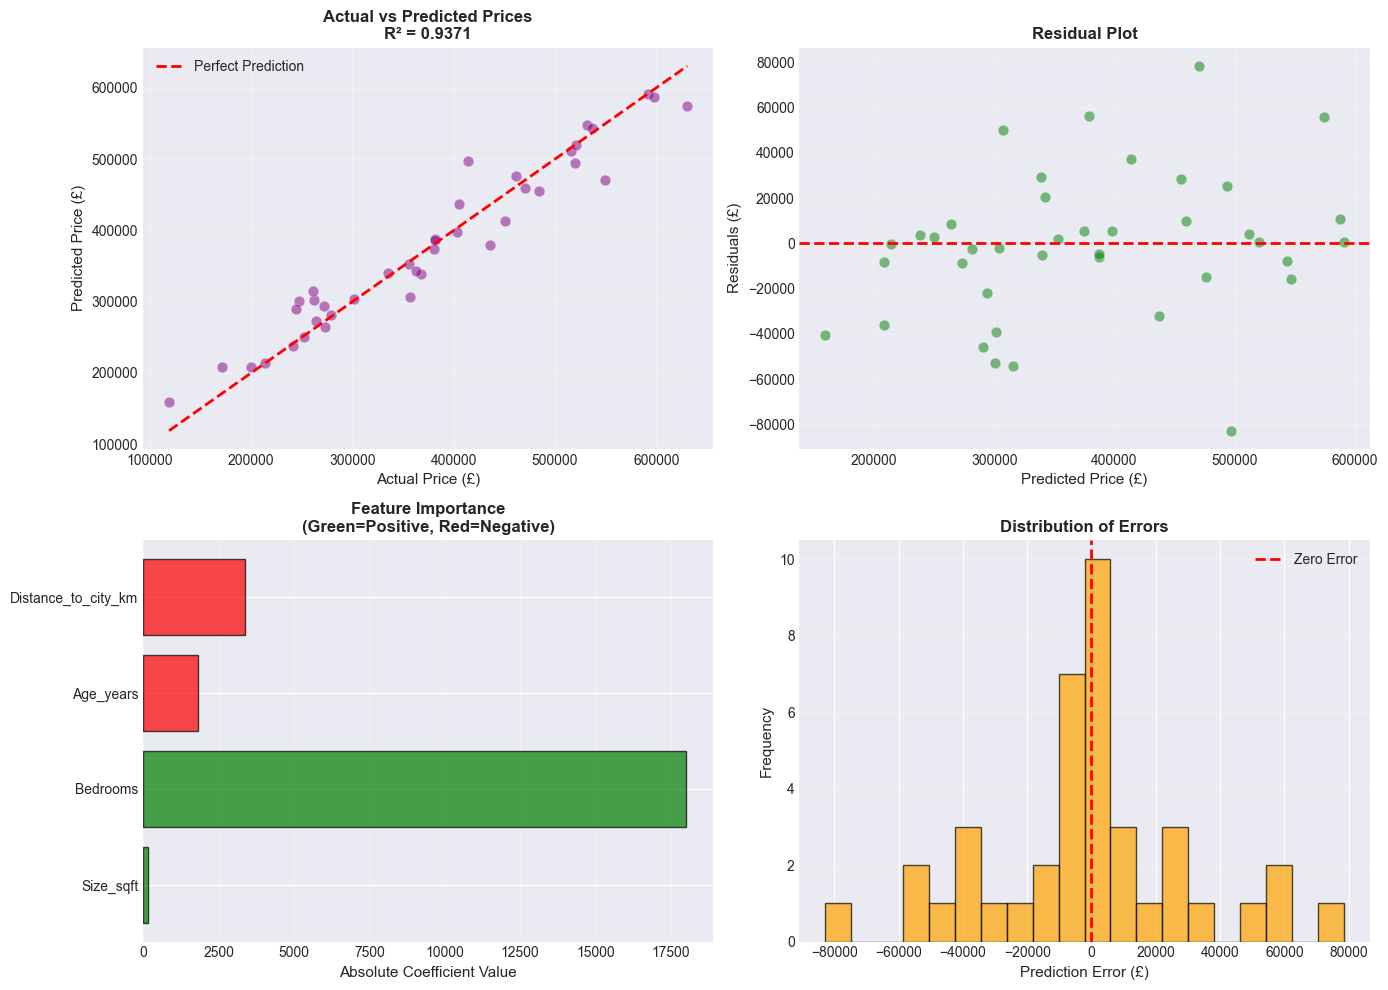


✅ Model performs well with multiple features!
   Combining multiple predictors gives better predictions than any single feature.


In [20]:
# Visualize Multiple Regression Results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test_h, y_pred_h, alpha=0.5, s=60, color='purple', 
                   edgecolors='white', linewidth=0.5)
perfect = np.linspace(y_test_h.min(), y_test_h.max(), 100)
axes[0, 0].plot(perfect, perfect, 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price (£)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Price (£)', fontsize=11)
axes[0, 0].set_title(f'Actual vs Predicted Prices\nR² = {r2_h:.4f}', 
                     fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals
residuals_h = y_test_h - y_pred_h
axes[0, 1].scatter(y_pred_h, residuals_h, alpha=0.5, s=60, color='green', 
                   edgecolors='white', linewidth=0.5)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Price (£)', fontsize=11)
axes[0, 1].set_ylabel('Residuals (£)', fontsize=11)
axes[0, 1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Feature Importance (Coefficients)
coef_abs = np.abs(house_model.coef_)
colors_coef = ['green' if c > 0 else 'red' for c in house_model.coef_]
bars = axes[1, 0].barh(feature_names, coef_abs, color=colors_coef, 
                       edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Absolute Coefficient Value', fontsize=11)
axes[1, 0].set_title('Feature Importance\n(Green=Positive, Red=Negative)', 
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Prediction Error Distribution
axes[1, 1].hist(residuals_h, bins=20, color='orange', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1, 1].set_xlabel('Prediction Error (£)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distribution of Errors', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✅ Model performs well with multiple features!")
print("   Combining multiple predictors gives better predictions than any single feature.")

🏠 Price Predictions for New Houses:

 Size_sqft  Bedrooms  Age_years  Distance_to_city_km  Predicted_Price
      1200         2          5                    5    300623.081453
      1800         3         10                   10    380446.567465
      2500         4          2                    3    539240.061238
      3000         5         20                   15    557026.395320


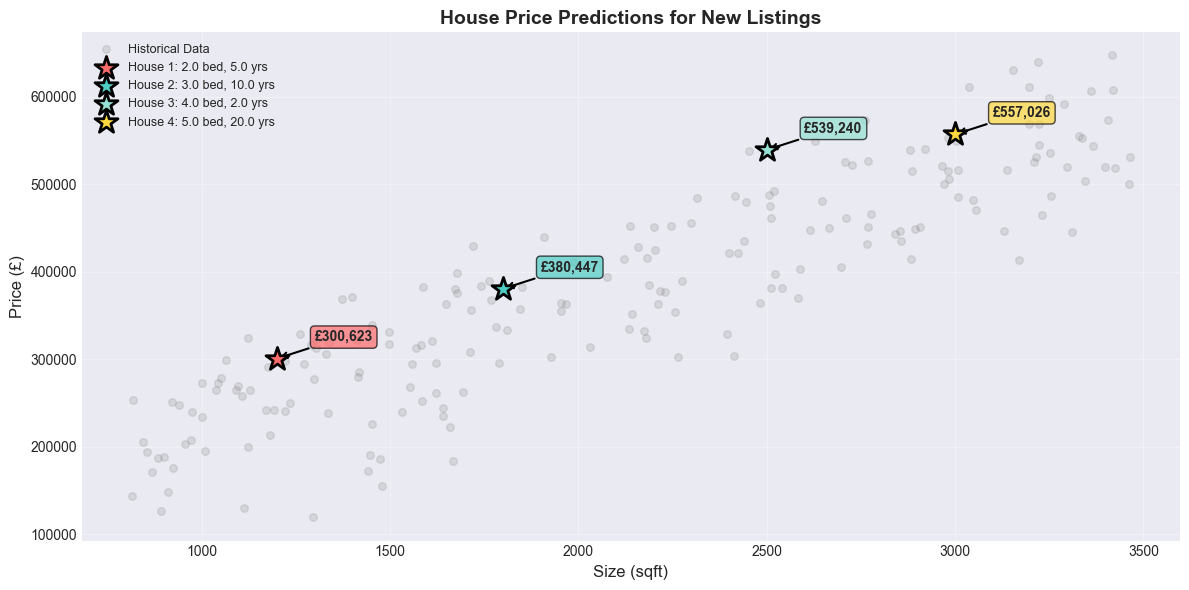


💰 Pricing Insights:
   These predictions help with:
   • Setting listing prices for sellers
   • Evaluating offers for buyers
   • Identifying over/under-priced properties
   • Real estate investment decisions


In [21]:
# Make predictions for new houses

print("🏠 Price Predictions for New Houses:\n")
print("="*80)

# Define some example houses
new_houses = pd.DataFrame({
    'Size_sqft': [1200, 1800, 2500, 3000],
    'Bedrooms': [2, 3, 4, 5],
    'Age_years': [5, 10, 2, 20],
    'Distance_to_city_km': [5, 10, 3, 15]
})

# Predict prices
predicted_prices = house_model.predict(new_houses)
new_houses['Predicted_Price'] = predicted_prices

print(new_houses.to_string(index=False))
print("="*80)

# Visualize predictions
fig, ax = plt.subplots(figsize=(12, 6))

# Plot historical data (faded)
ax.scatter(house_data['Size_sqft'], house_data['Price'], 
          alpha=0.2, s=30, color='gray', label='Historical Data')

# Plot predictions (highlighted)
colors_new = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFD93D']
for idx, row in new_houses.iterrows():
    ax.scatter(row['Size_sqft'], row['Predicted_Price'], 
              s=300, marker='*', color=colors_new[idx], 
              edgecolors='black', linewidth=2, zorder=5,
              label=f'House {idx+1}: {row["Bedrooms"]} bed, {row["Age_years"]} yrs')
    ax.annotate(f'£{row["Predicted_Price"]:,.0f}', 
               xy=(row['Size_sqft'], row['Predicted_Price']),
               xytext=(row['Size_sqft']+100, row['Predicted_Price']+20000),
               fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor=colors_new[idx], alpha=0.7),
               arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.set_xlabel('Size (sqft)', fontsize=12)
ax.set_ylabel('Price (£)', fontsize=12)
ax.set_title('House Price Predictions for New Listings', 
            fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💰 Pricing Insights:")
print("   These predictions help with:")
print("   • Setting listing prices for sellers")
print("   • Evaluating offers for buyers")
print("   • Identifying over/under-priced properties")
print("   • Real estate investment decisions")

---

## 11. Polynomial Regression <a id="11"></a>

Sometimes the relationship isn't perfectly linear. **Polynomial Regression** can model curves!

Instead of: $y = \theta_0 + \theta_1 x$

We use: $y = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 + ...$

This is still "linear" regression because it's linear in the **parameters** $\theta$!

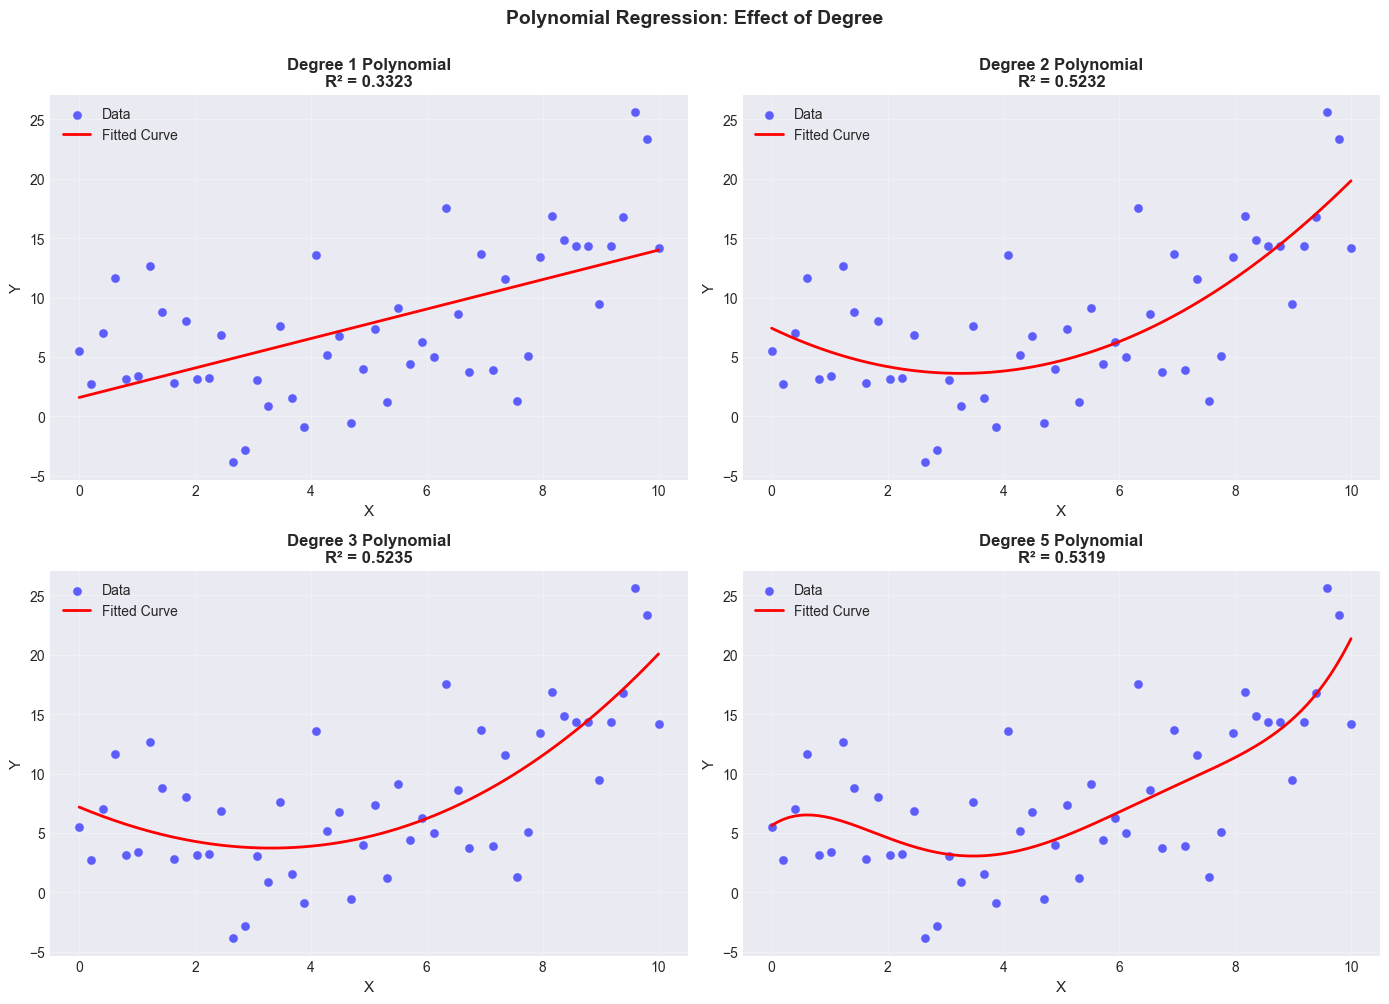


📊 Polynomial Regression Insights:

   Degree 1 (Linear): Simple but may underfit curved data
   Degree 2-3: Often the sweet spot for real data
   Degree 5+: May overfit (fits noise, not signal)

💡 Key Principle: Balance between fitting data and generalizing to new data!


In [22]:
# Demonstrate Polynomial Regression

# Generate non-linear data
np.random.seed(42)
X_poly = np.linspace(0, 10, 50)
y_poly = 3 + 2*X_poly - 0.5*X_poly**2 + 0.05*X_poly**3 + np.random.normal(0, 5, 50)

X_poly_reshaped = X_poly.reshape(-1, 1)

# Fit different polynomial degrees
degrees = [1, 2, 3, 5]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, degree in enumerate(degrees):
    # Create polynomial features
    poly_features = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly_features.fit_transform(X_poly_reshaped)
    
    # Fit model
    poly_model = LinearRegression()
    poly_model.fit(X_poly_transformed, y_poly)
    
    # Predict
    X_line = np.linspace(0, 10, 200).reshape(-1, 1)
    X_line_poly = poly_features.transform(X_line)
    y_line = poly_model.predict(X_line_poly)
    
    # Calculate R²
    y_pred_poly = poly_model.predict(X_poly_transformed)
    r2_poly = r2_score(y_poly, y_pred_poly)
    
    # Plot
    axes[idx].scatter(X_poly, y_poly, alpha=0.6, s=50, color='blue', 
                     edgecolors='white', linewidth=1, label='Data')
    axes[idx].plot(X_line, y_line, 'r-', linewidth=2, label='Fitted Curve')
    axes[idx].set_xlabel('X', fontsize=11)
    axes[idx].set_ylabel('Y', fontsize=11)
    axes[idx].set_title(f'Degree {degree} Polynomial\nR² = {r2_poly:.4f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Polynomial Regression: Effect of Degree', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n📊 Polynomial Regression Insights:")
print("\n   Degree 1 (Linear): Simple but may underfit curved data")
print("   Degree 2-3: Often the sweet spot for real data")
print("   Degree 5+: May overfit (fits noise, not signal)")
print("\n💡 Key Principle: Balance between fitting data and generalizing to new data!")

---

## 12. Regularization Techniques <a id="12"></a>

**Problem**: Complex models can **overfit** - they memorize training data but perform poorly on new data.

**Solution**: **Regularization** - penalize complex models to prefer simpler ones.

### Ridge Regression (L2 Regularization)

Adds penalty proportional to **square of coefficients**:

$$J(\theta) = MSE(\theta) + \alpha \sum_{i=1}^{n} \theta_i^2$$

- Shrinks coefficients but doesn't set them to zero
- Good when all features are somewhat relevant

### Lasso Regression (L1 Regularization)

Adds penalty proportional to **absolute value of coefficients**:

$$J(\theta) = MSE(\theta) + \alpha \sum_{i=1}^{n} |\theta_i|$$

- Can set coefficients exactly to zero
- Performs **feature selection** automatically
- Good when many features are irrelevant

### $\alpha$ (Alpha) Parameter

- **α = 0**: Regular linear regression (no regularization)
- **Small α**: Little regularization
- **Large α**: Strong regularization (simpler model)

🔍 Comparing Regularization Techniques

Linear Regression    | R²: 0.9371 | RMSE: $31,995
                      Coefficients: [146.44, 18003.79, -1822.10, -3386.57]
----------------------------------------------------------------------------------------------------
Ridge (α=100)        | R²: 0.9279 | RMSE: $34,255
                      Coefficients: [145.37, 13739.51, -1801.84, -3258.21]
----------------------------------------------------------------------------------------------------
Ridge (α=1000)       | R²: 0.8917 | RMSE: $41,986
                      Coefficients: [142.82, 4353.75, -1732.13, -2803.61]
----------------------------------------------------------------------------------------------------
Lasso (α=100)        | R²: 0.9370 | RMSE: $32,015
                      Coefficients: [146.42, 17953.10, -1821.54, -3383.87]
----------------------------------------------------------------------------------------------------
Lasso (α=1000)       | R²: 0.9363 | RMSE: $32,203
        

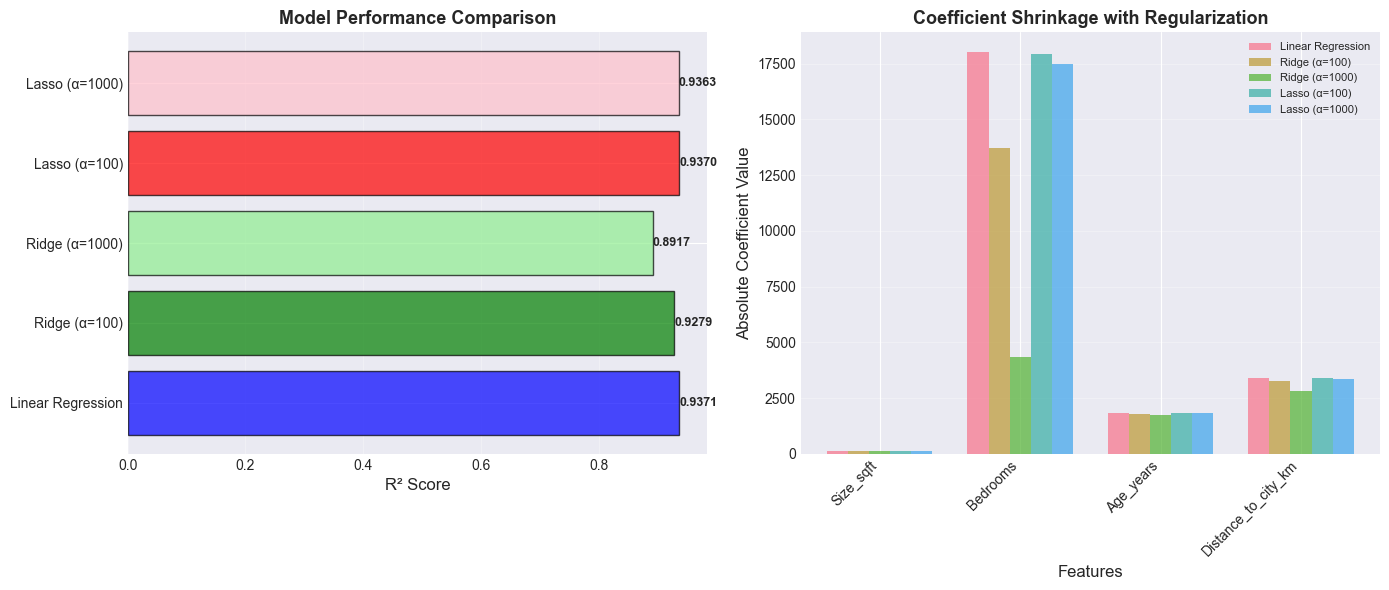


💡 Regularization Insights:
   • Ridge: Shrinks all coefficients (good for correlated features)
   • Lasso: Can zero out coefficients (automatic feature selection)
   • Higher α = more regularization = simpler model
   • Trade-off: Simpler models generalize better but may underfit


In [23]:
# Compare Regular, Ridge, and Lasso Regression

from sklearn.linear_model import Ridge, Lasso

# Use house data
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=100)': Ridge(alpha=100),
    'Ridge (α=1000)': Ridge(alpha=1000),
    'Lasso (α=100)': Lasso(alpha=100),
    'Lasso (α=1000)': Lasso(alpha=1000)
}

results = []

print("🔍 Comparing Regularization Techniques\n")
print("="*100)

for name, model in models.items():
    # Train
    model.fit(X_train_h, y_train_h)
    
    # Evaluate
    y_pred_reg = model.predict(X_test_h)
    r2 = r2_score(y_test_h, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_reg))
    
    # Store results
    results.append({
        'Model': name,
        'R²': r2,
        'RMSE': rmse,
        'Coefficients': model.coef_
    })
    
    print(f"{name:20s} | R²: {r2:.4f} | RMSE: ${rmse:,.0f}")
    print(f"                      Coefficients: [{', '.join([f'{c:.2f}' for c in model.coef_])}]")
    print("-"*100)

# Visualize coefficient changes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: R² comparison
model_names = [r['Model'] for r in results]
r2_scores = [r['R²'] for r in results]
colors = ['blue', 'green', 'lightgreen', 'red', 'pink']

bars = axes[0].barh(model_names, r2_scores, color=colors, 
                    edgecolor='black', alpha=0.7)
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, score in zip(bars, r2_scores):
    axes[0].text(score, bar.get_y() + bar.get_height()/2, 
                f'{score:.4f}', va='center', ha='left', 
                fontsize=9, fontweight='bold')

# Plot 2: Coefficient magnitudes
x_pos = np.arange(len(feature_names))
width = 0.15

for idx, result in enumerate(results):
    offset = (idx - 2) * width
    axes[1].bar(x_pos + offset, np.abs(result['Coefficients']), 
               width, label=result['Model'], alpha=0.7)

axes[1].set_xlabel('Features', fontsize=12)
axes[1].set_ylabel('Absolute Coefficient Value', fontsize=12)
axes[1].set_title('Coefficient Shrinkage with Regularization', 
                 fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(feature_names, rotation=45, ha='right')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n💡 Regularization Insights:")
print("   • Ridge: Shrinks all coefficients (good for correlated features)")
print("   • Lasso: Can zero out coefficients (automatic feature selection)")
print("   • Higher α = more regularization = simpler model")
print("   • Trade-off: Simpler models generalize better but may underfit")

---

## 13. Best Practices & Conclusion <a id="13"></a>

### ✅ Best Practices for Linear Regression

#### 📊 Data Preparation
- ✓ **Check for linearity**: Plot features vs target
- ✓ **Handle missing values**: Impute or remove
- ✓ **Remove outliers**: Can dramatically affect the fit line
- ✓ **Scale features**: Especially important for regularization
- ✓ **Check for multicollinearity**: Highly correlated features can cause issues

#### 🎯 Model Building
- ✓ **Split data**: Always use train/test split
- ✓ **Start simple**: Try linear before polynomial
- ✓ **Feature engineering**: Create meaningful features
- ✓ **Use regularization**: Prevent overfitting
- ✓ **Cross-validation**: For robust evaluation

#### 📈 Model Evaluation
- ✓ **Multiple metrics**: R², RMSE, MAE
- ✓ **Residual analysis**: Check assumptions
- ✓ **Visual inspection**: Always plot results
- ✓ **Domain validation**: Do predictions make sense?

### ⚠️ When NOT to Use Linear Regression

Avoid linear regression when:
- ❌ Relationship is clearly non-linear (try polynomial or other algorithms)
- ❌ Target variable is categorical (use logistic regression or classification)
- ❌ Severe outliers that can't be removed
- ❌ Features are heavily correlated (multicollinearity)
- ❌ Need to predict probability (0-1 range)

### 🎓 Key Takeaways

1. **Linear Regression finds the best-fit line** through data by minimizing errors
2. **Simple yet powerful** - works well for many real-world problems
3. **Interpretable** - coefficients show feature importance and direction
4. **Foundation for ML** - concepts apply to more advanced algorithms
5. **Always evaluate** - don't just train, test your model!
6. **Assumptions matter** - check linearity, normality, homoscedasticity
7. **Regularization prevents overfitting** - use Ridge/Lasso for complex models


### 📚 You now know:

- ✅ What machine learning is and its types
- ✅ How linear regression works mathematically
- ✅ How to implement from scratch and use scikit-learn
- ✅ How to evaluate models properly
- ✅ How to apply regression to real problems
- ✅ Advanced techniques (polynomial, regularization)


In [ ]:
# Final Summary Visualization

print("\n" + "="*80)
print("  LINEAR REGRESSION - SUMMARY")
print("="*80)

summary_data = {
    'Concept': [
        'Simple Linear Regression',
        'Multiple Linear Regression', 
        'Polynomial Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'Equation': [
        'y = θ₀ + θ₁x',
        'y = θ₀ + θ₁x₁ + θ₂x₂ + ...',
        'y = θ₀ + θ₁x + θ₂x² + ...',
        'MSE + α∑θᵢ²',
        'MSE + α∑|θᵢ|'
    ],
    'Use Case': [
        'One predictor variable',
        'Multiple predictor variables',
        'Non-linear relationships',
        'Prevent overfitting',
        'Feature selection'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n📊 Regression Techniques Summary:\n")
print(summary_df.to_string(index=False))

print("\n" + "="*80)